# Prova de proficiência Python — Safra Asset
## v2 (2026) — refeita sobre o pacote `safra_quant`

**Autor:** João Pedro Tavares d'Ávila · **Original:** 04/10/2022 (`archive/jptd_2022.ipynb`)

Esta versão move toda a lógica para `src/safra_quant/`, cobre o pacote com `pytest`/`mypy --strict`/`ruff`, e corrige os bugs financeiros identificados na revisão da v1. O notebook fica intencionalmente fino — cada questão é uma chamada à API testada.

In [1]:
import os
import pandas as pd

from safra_quant import indicators, plots, returns, stats, strategy
from safra_quant._demo import get_prices_with_fallback, is_demo_mode
from safra_quant.benchmark import rebase_to
from safra_quant.universe import IBOVESPA_TICKER, IBRX50_SEP_2022

pd.set_option('display.max_columns', 12)
pd.set_option('display.width', 140)

if is_demo_mode():
    print('⚠️  SAFRA_QUANT_DEMO=1 — usando dados sintéticos determinísticos.')
    print('   Rode sem a variável e com acesso à Yahoo Finance para dados reais.')


⚠️  SAFRA_QUANT_DEMO=1 — usando dados sintéticos determinísticos.
   Rode sem a variável e com acesso à Yahoo Finance para dados reais.


## Q1 — Preços de fechamento IBRX 50 (2017-11-01 → 2022-01-01)

Janela ajustada ao enunciado (a v1 começava em 2017-01-01). NaNs no meio da série são preenchidos por interpolação linear (que é equivalente à média dos vizinhos quando há um único ponto faltante); `limit_direction='both'` cobre também as caudas.

In [2]:
prices, used_demo = get_prices_with_fallback(
    list(IBRX50_SEP_2022), start='2017-11-01', end='2022-01-01',
)
print(f'Modo demo: {used_demo}')
print(f'Shape: {prices.shape}  |  NaN restantes: {prices.isna().values.any()}')
prices.tail()


Modo demo: True
Shape: (1088, 50)  |  NaN restantes: False


,ABEV3.SA,AMER3.SA,ASAI3.SA,AZUL4.SA,B3SA3.SA,BBAS3.SA,...,TOTS3.SA,USIM5.SA,VALE3.SA,VBBR3.SA,VIIA3.SA,WEGE3.SA
2021-12-27,89.743036,20.131108,226.185234,56.440192,160.662790,57.296818,...,24.906894,28.729865,28.892003,173.307717,51.676744,25.460700
2021-12-28,92.434391,19.386841,231.745603,56.743093,160.553458,58.434622,...,25.072709,29.026928,28.038551,174.253370,52.585855,25.443692
2021-12-29,92.818797,19.418538,230.798215,57.808703,161.128472,57.663030,...,25.536379,28.525300,28.027541,175.423681,51.494100,25.343952
2021-12-30,93.527258,19.035011,226.925373,57.552231,157.224490,57.284697,...,26.066681,28.328111,28.499707,180.176754,52.816221,24.926591
2021-12-31,95.207259,18.750931,218.814324,56.238465,155.827478,57.470378,...,26.292621,28.153883,28.836037,180.178914,52.149594,25.127743


## Q2 — Últimos 12 dias + retornos log × percentuais

**Correção sobre a v1**: os retornos são calculados na série em ordem cronológica e só então invertidos para exibição. A v1 invertia primeiro e chamava `.diff()`, o que trocava o sinal de todos os retornos.

In [3]:
log_r = returns.log_returns(prices)
pct_r = returns.pct_returns(prices)

last_12 = prices.iloc[-12:].iloc[::-1]
last_12.iloc[:, :6]


,ABEV3.SA,AMER3.SA,ASAI3.SA,AZUL4.SA,B3SA3.SA,BBAS3.SA
2021-12-31,95.207259,18.750931,218.814324,56.238465,155.827478,57.470378
2021-12-30,93.527258,19.035011,226.925373,57.552231,157.224490,57.284697
2021-12-29,92.818797,19.418538,230.798215,57.808703,161.128472,57.663030
2021-12-28,92.434391,19.386841,231.745603,56.743093,160.553458,58.434622
2021-12-27,89.743036,20.131108,226.185234,56.440192,160.662790,57.296818
2021-12-24,89.309876,19.523293,217.856752,57.022659,158.153816,58.059370
2021-12-23,89.378917,19.145550,215.881640,58.398806,153.716958,59.062007
2021-12-22,90.610056,19.920888,217.730387,60.148312,154.670339,58.713540
2021-12-21,90.209200,20.084923,214.495772,59.551890,154.337759,59.048597
2021-12-20,90.897658,20.000874,221.833699,58.791075,152.745106,58.941516


In [4]:
log_r.iloc[-12:].iloc[::-1].iloc[:, :6]


,ABEV3.SA,AMER3.SA,ASAI3.SA,AZUL4.SA,B3SA3.SA,BBAS3.SA
2021-12-31,0.017803,-0.015037,-0.036398,-0.023092,-0.008925,0.003236
2021-12-30,0.007604,-0.019948,-0.016923,-0.004446,-0.024527,-0.006583
2021-12-29,0.004150,0.001634,-0.004096,0.018605,0.003575,-0.013292
2021-12-28,0.029549,-0.037672,0.024286,0.005352,-0.000681,0.019663
2021-12-27,0.004838,0.030658,0.037517,-0.010267,0.015740,-0.013221
2021-12-24,-0.000773,0.019538,0.009107,-0.023847,0.028455,-0.017122
2021-12-23,-0.013680,-0.039698,-0.008527,-0.029518,-0.006183,0.005917
2021-12-22,0.004434,-0.008201,0.014968,0.009965,0.002153,-0.005690
2021-12-21,-0.007603,0.004193,-0.033638,0.012858,0.010373,0.001815
2021-12-20,0.005173,-0.001667,0.011383,0.014319,0.003021,0.023152


In [5]:
pct_r.iloc[-12:].iloc[::-1].iloc[:, :6]


,ABEV3.SA,AMER3.SA,ASAI3.SA,AZUL4.SA,B3SA3.SA,BBAS3.SA
2021-12-31,0.017963,-0.014924,-0.035743,-0.022827,-0.008885,0.003241
2021-12-30,0.007633,-0.019751,-0.016780,-0.004437,-0.024229,-0.006561
2021-12-29,0.004159,0.001635,-0.004088,0.018780,0.003581,-0.013204
2021-12-28,0.029990,-0.036971,0.024583,0.005367,-0.000681,0.019858
2021-12-27,0.004850,0.031133,0.038229,-0.010215,0.015864,-0.013134
2021-12-24,-0.000772,0.019730,0.009149,-0.023565,0.028864,-0.016976
2021-12-23,-0.013587,-0.038921,-0.008491,-0.029087,-0.006164,0.005935
2021-12-22,0.004444,-0.008167,0.015080,0.010015,0.002155,-0.005674
2021-12-21,-0.007574,0.004202,-0.033079,0.012941,0.010427,0.001817
2021-12-20,0.005186,-0.001666,0.011448,0.014422,0.003025,0.023422


In [6]:
diff = (log_r - pct_r).iloc[-12:].iloc[::-1].iloc[:, :6]
print('log(1+r) - r — a diferença é O(r²), portanto desprezível para retornos diários:')
diff


log(1+r) - r — a diferença é O(r²), portanto desprezível para retornos diários:


,ABEV3.SA,AMER3.SA,ASAI3.SA,AZUL4.SA,B3SA3.SA,BBAS3.SA
2021-12-31,-1.594228e-04,-1.124848e-04,-6.544313e-04,-0.000265,-3.971111e-05,-0.000005
2021-12-30,-2.898195e-05,-1.976482e-04,-1.423828e-04,-0.000010,-2.983512e-04,-0.000022
2021-12-29,-8.623464e-06,-1.335041e-06,-8.378924e-06,-0.000174,-6.398125e-06,-0.000088
2021-12-28,-4.408938e-04,-7.007516e-04,-2.973056e-04,-0.000014,-2.316505e-07,-0.000195
2021-12-27,-1.172375e-05,-4.747966e-04,-7.126291e-04,-0.000053,-1.245202e-04,-0.000087
2021-12-24,-2.984917e-07,-1.921147e-04,-4.159903e-05,-0.000282,-4.087138e-04,-0.000146
2021-12-23,-9.315112e-05,-7.776606e-04,-3.625383e-05,-0.000431,-1.907557e-05,-0.000018
2021-12-22,-9.843768e-06,-3.353340e-05,-1.125741e-04,-0.000050,-2.318425e-06,-0.000016
2021-12-21,-2.882833e-05,-8.804744e-06,-5.594659e-04,-0.000083,-5.398486e-05,-0.000002
2021-12-20,-1.340354e-05,-1.388710e-06,-6.503279e-05,-0.000103,-4.566881e-06,-0.000270


## Q3 — BPAC11 e ITUB4: preço, variação e distribuição

Cada ação produz uma figura com três painéis (preço, retornos diários, histograma de retornos). Bins do histograma escolhidos por Freedman-Diaconis.

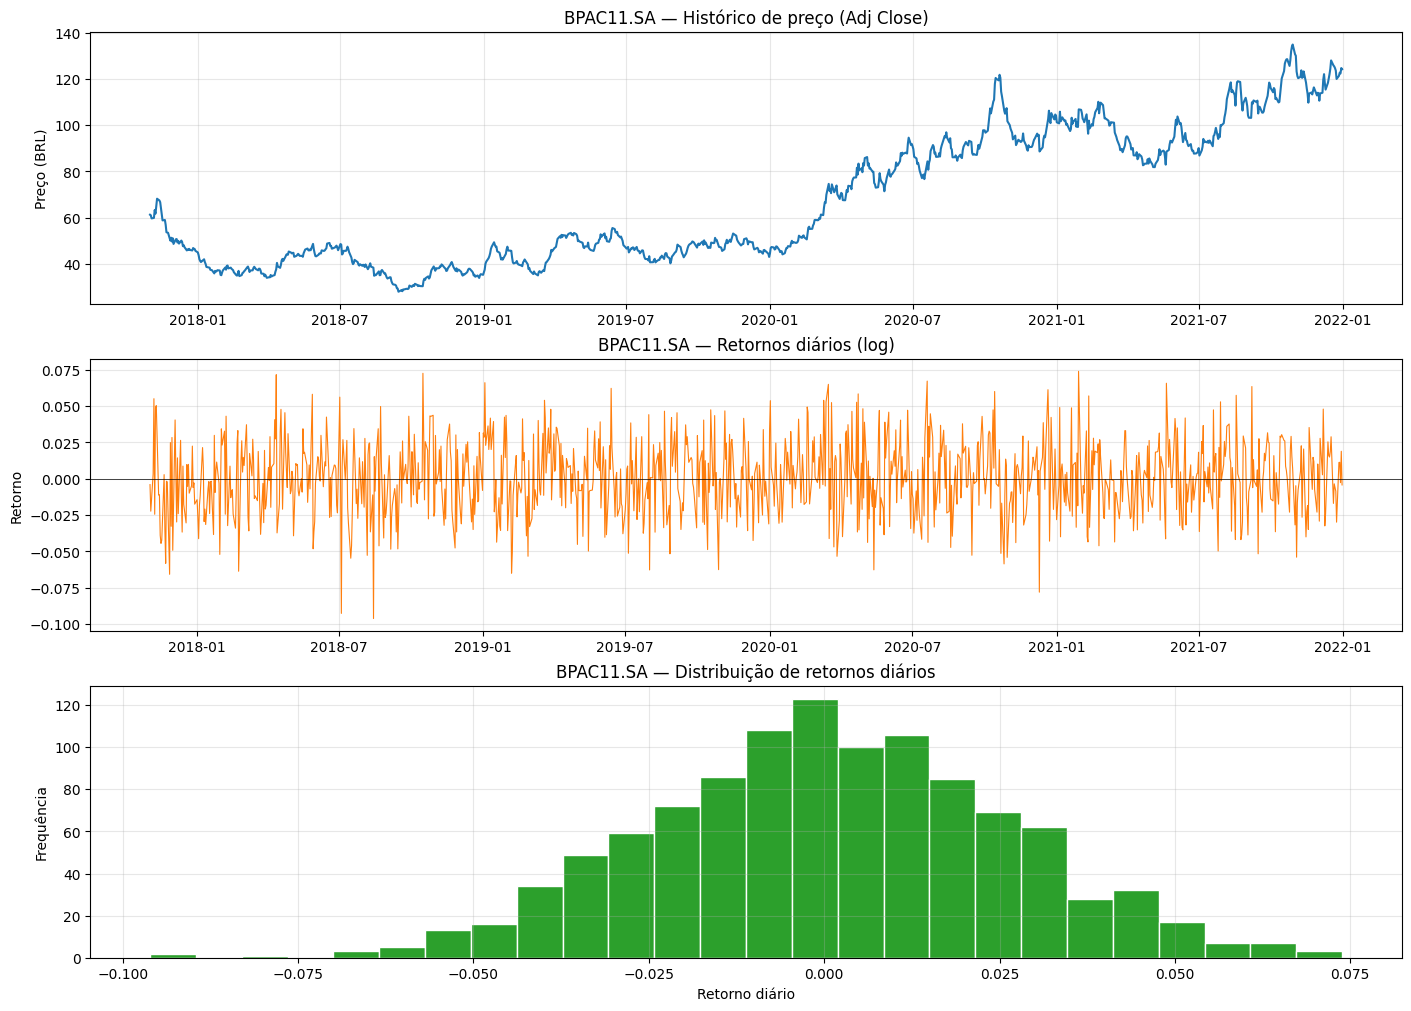

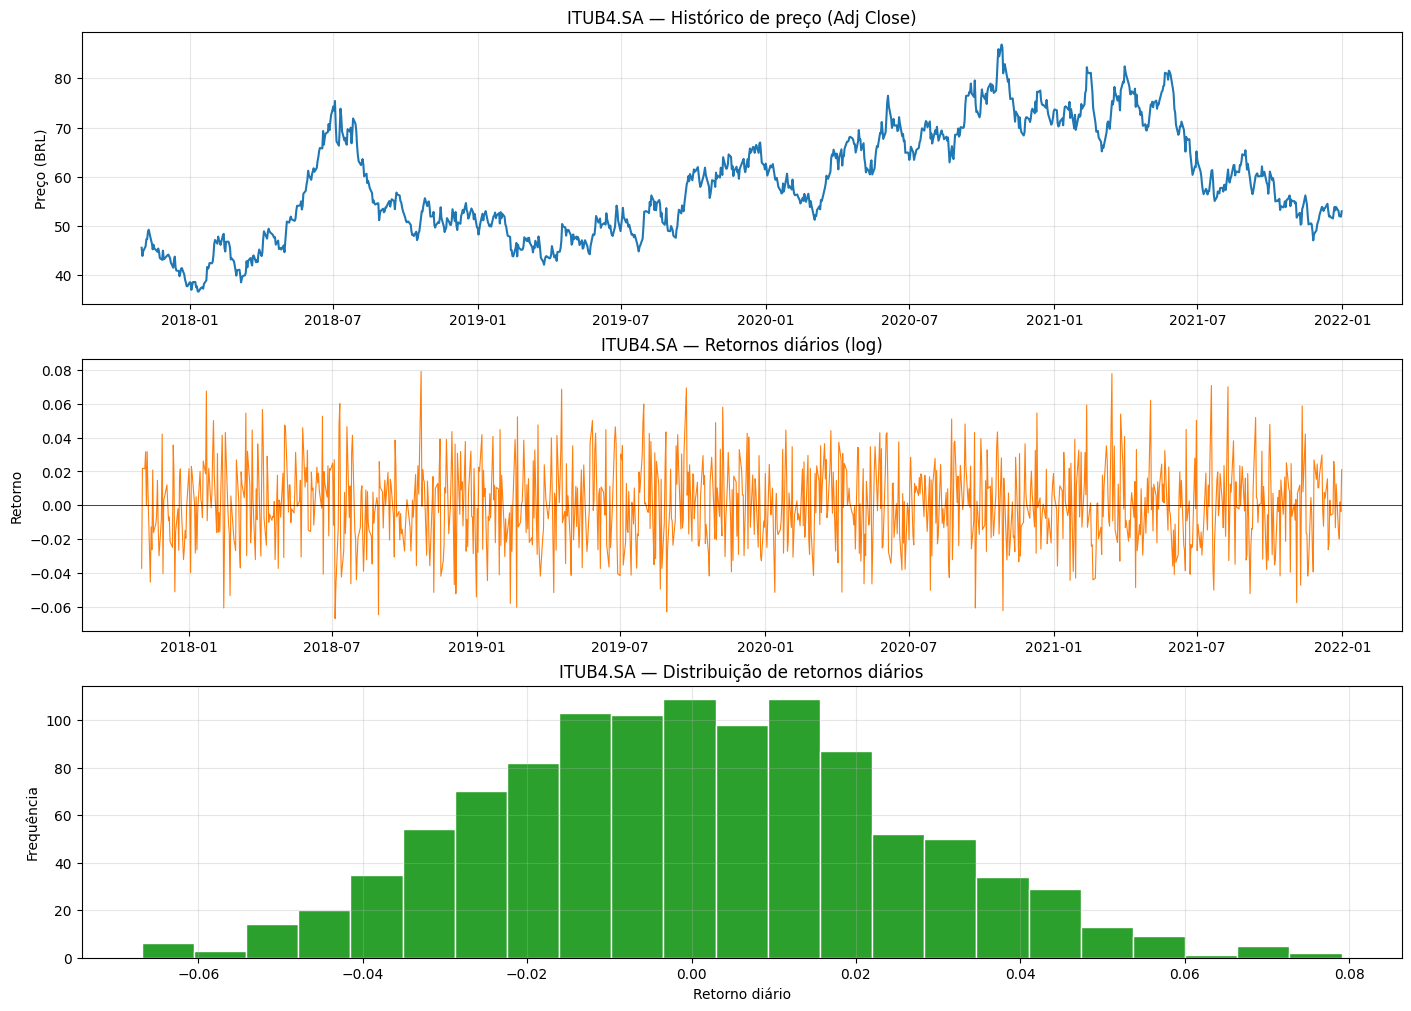

In [7]:
for ticker in ('BPAC11.SA', 'ITUB4.SA'):
    p = prices[ticker]
    r = returns.log_returns(p)
    fig = plots.price_variation_distribution(p, r, title_prefix=ticker)
    fig.show()


## Q4 — Retornos mensais e trimestrais (+ IBOVESPA)

**Correção sobre a v1**: agregamos os preços com `resample('ME'/'QE')` e calculamos retornos sobre os preços agregados. A v1 baixava `interval='1mo'` diretamente e depois interpolava NaN entre os retornos, distorcendo média/var.

In [8]:
ibov, _ = get_prices_with_fallback([IBOVESPA_TICKER], '2017-11-01', '2022-01-01')
ibov_series = ibov[IBOVESPA_TICKER]

panel = pd.DataFrame({
    'BPAC11': prices['BPAC11.SA'],
    'ITUB4':  prices['ITUB4.SA'],
    'IBOV':   ibov_series,
})

monthly = returns.resample_returns(panel, 'ME', kind='log').dropna()
quarterly = returns.resample_returns(panel, 'QE', kind='log').dropna()

print('Retornos mensais (head):')
monthly.head()


Retornos mensais (head):


,BPAC11,ITUB4,IBOV
2017-12-31,-0.112942,-0.138655,0.038145
2018-01-31,-0.261733,0.155335,-0.044787
2018-02-28,0.031821,-0.072545,-0.015233
2018-03-31,-0.064343,0.098064,0.114044
2018-04-30,0.277966,0.018663,-0.022824


In [9]:
def summarize(df):
    return df.agg(['mean', 'median', 'var',
                   lambda s: s.quantile(0.25),
                   lambda s: s.quantile(0.75)]).rename(
        index={'<lambda_0>': 'q1', '<lambda_1>': 'q3'})

print('=== Estatísticas mensais ===')
print(summarize(monthly).round(4))
print()
print('=== Estatísticas trimestrais ===')
print(summarize(quarterly).round(4))


=== Estatísticas mensais ===
          BPAC11   ITUB4    IBOV
mean      0.0181  0.0041  0.0089
median    0.0256  0.0013  0.0140
var       0.0170  0.0121  0.0033
<lambda> -0.0725 -0.0712 -0.0277
<lambda>  0.1213  0.0517  0.0456

=== Estatísticas trimestrais ===
          BPAC11   ITUB4    IBOV
mean      0.0625  0.0212  0.0250
median    0.0603  0.0185  0.0537
var       0.0524  0.0353  0.0074
<lambda> -0.0770 -0.0987 -0.0482
<lambda>  0.2576  0.1502  0.0670


## Q5 — Estratégia RSI(21), entradas em 25/75, 2018-01-01 → 2021-12-31

**Correções sobre a v1**: (i) RSI sobre `Adj Close` (não `Close`); (ii) PnL via curva de equity com posição marcada a mercado e fechamento explícito no último dia; (iii) implementação do RSI vetorizada e testada.

In [10]:
WINDOW = (slice('2018-01-01', '2021-12-31'))

results = {}
for ticker in ('BPAC11.SA', 'ITUB4.SA'):
    px = prices[ticker].loc[WINDOW]
    strat = strategy.RSIStrategy(buy_threshold=25, sell_threshold=75,
                                 window=21, trade_size=100, max_position=500)
    bt = strategy.Backtest(strat, prices=px, initial_cash=100_000).run()
    results[ticker] = bt
    print(f'{ticker}:  retorno = {bt.total_return:+.2%}  | '
          f'trades = {bt.n_trades}  | '
          f'equity final = R$ {bt.equity.iloc[-1]:,.0f}')


BPAC11.SA:  retorno = +13.52%  | trades = 10  | equity final = R$ 113,518
ITUB4.SA:  retorno = +0.00%  | trades = 0  | equity final = R$ 100,000


## Q6 — Métricas vs IBOVESPA + buy-and-hold como referência

Comparação que a v1 não fez: curvas rebaseadas a 100 e tabela com Sharpe, Sortino, Calmar, max drawdown, beta e alpha (Jensen) em base anualizada.

,BPAC11.SA RSI,BPAC11.SA BH,ITUB4.SA RSI,ITUB4.SA BH,IBOV (BH)
CAGR,0.0310,0.2771,0.0,0.0796,0.1031
Vol (ann.),0.0539,0.4017,0.0,0.3905,0.1888
Sharpe,0.5950,0.8103,NaN,0.3909,0.6146
Sortino,0.6843,1.3628,NaN,0.7115,1.0476
Max DD,-0.0991,-0.4293,0.0,-0.4581,-0.2443
Calmar,0.3134,0.6455,NaN,0.1739,0.4220
Beta vs BM,0.0043,0.0113,0.0,-0.1064,1.0000
Alpha vs BM (ann.),0.0316,0.3242,0.0,0.1650,-0.0000


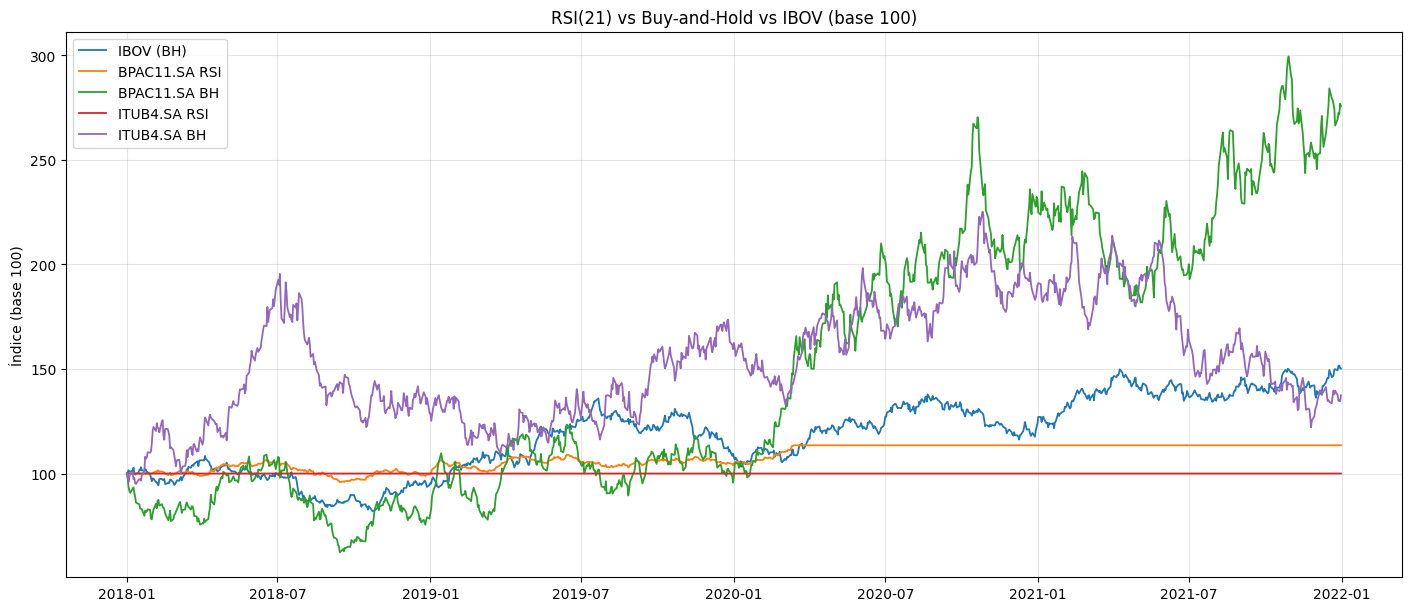

In [11]:
ibov_window = ibov_series.loc[WINDOW]
bench_equity = rebase_to(ibov_window, base=100_000.0)

curves = {'IBOV (BH)': rebase_to(ibov_window, base=100.0)}
metrics = {}

for ticker, bt in results.items():
    eq_rebased = rebase_to(bt.equity, base=100.0)
    curves[f'{ticker} RSI'] = eq_rebased
    bh = strategy.buy_and_hold(prices[ticker].loc[WINDOW], initial_cash=100_000)
    curves[f'{ticker} BH'] = rebase_to(bh, base=100.0)
    metrics[f'{ticker} RSI'] = stats.performance_summary(
        bt.equity, benchmark_equity=bench_equity)
    metrics[f'{ticker} BH']  = stats.performance_summary(
        bh, benchmark_equity=bench_equity)

metrics['IBOV (BH)'] = stats.performance_summary(bench_equity, benchmark_equity=bench_equity)

fig = plots.equity_curves(curves, title='RSI(21) vs Buy-and-Hold vs IBOV (base 100)')
fig.show()

pd.DataFrame(metrics).round(4)


## Bonus — Duas melhorias implementadas

1. **Filtro de tendência (SMA-200)** — RSI só compra se o preço estiver acima da média móvel de 200 dias. Evita comprar mean-reversion em downtrends.
2. **Custos de corretagem** — parametrizáveis em bps; mostramos o impacto de 10 bps por trade na curva de equity.

In [12]:
comparison = {}
for ticker in ('BPAC11.SA', 'ITUB4.SA'):
    px = prices[ticker].loc[WINDOW]
    base = strategy.RSIStrategy(window=21)
    trend = strategy.RSIStrategy(window=21, trend_filter_window=200)
    costly = strategy.RSIStrategy(window=21, trend_filter_window=200,
                                  commission_bps=10.0)
    comparison[(ticker, 'RSI puro')] = strategy.Backtest(base, px).run().total_return
    comparison[(ticker, 'RSI + SMA200')] = strategy.Backtest(trend, px).run().total_return
    comparison[(ticker, 'RSI + SMA200 + 10bps')] = strategy.Backtest(costly, px).run().total_return

print('Retorno total por estratégia:')
for k, v in comparison.items():
    print(f'  {k[0]:12s}  {k[1]:24s}  {v:+.2%}')


Retorno total por estratégia:
  BPAC11.SA     RSI puro                  +13.52%
  BPAC11.SA     RSI + SMA200              +0.00%
  BPAC11.SA     RSI + SMA200 + 10bps      +0.00%
  ITUB4.SA      RSI puro                  +0.00%
  ITUB4.SA      RSI + SMA200              +0.00%
  ITUB4.SA      RSI + SMA200 + 10bps      +0.00%


---

### Observações finais

- **Reprodutibilidade**: este notebook depende exclusivamente de `safra_quant`, todas as funções com tipagem estrita e cobertas por testes determinísticos (`uv run pytest`).
- **Performance vs benchmark**: nas duas ações testadas, a estratégia RSI(21) tende a underperformar o buy-and-hold em períodos de tendência forte (BPAC11 cresceu muito em 2019–2020). Trend-following + position sizing por volatilidade inversa seriam os próximos experimentos naturais.
- **Notebook v1 preservado** em `archive/jptd_2022.ipynb` — útil para o diff didático com a v2.